# Phân tích khám phá dữ liệu (EDA) — OULAD

**DSP391m · Nhóm 1 · Đại học FPT** · Đề tài: *Time-Aware Explainable ML for Early At-Risk Student Prediction on OULAD* · GVHD: Nguyễn Thị Hoàng Yến

> Notebook này là **bản chạy thật** của khối EDA trong báo cáo Task 3, khớp với slide **18–22** và kịch bản thuyết trình (`reports/Task3_Speaker_Script_VI.md`). Mọi phân tích gọi qua module đã kiểm thử `src/eda/eda.py` nên hình và bảng **không bị lệch** so với code; các con số in ra chính là số dùng trên slide.

**Mạch phân tích (bốn góc nhìn):** từng biến một (univariate) → biến theo nhãn (bivariate) → các biến với nhau & kiểm tra rò rỉ (multivariate) → theo thời gian (time-aware, RQ1); kèm chất lượng dữ liệu, phân phối lớp, và tín hiệu sinh viên rút môn.

## 0. Mục tiêu EDA & nạp dữ liệu  *(Slide 18)*

**Làm gì:** hiểu dữ liệu (≈32.593 bản ghi, 33 biến, 3 nhóm), kiểm tra chất lượng, và tìm biến phân biệt được sinh viên nguy cơ.

**Vì sao:** EDA không phải để trang trí — mỗi biểu đồ dẫn tới một quyết định: *chọn đặc trưng* hoặc *kiểm chứng không rò rỉ*.

**Kết quả:** ba kết luận định hướng (xem mục cuối). Dùng `master_raw` (t=100%) cho univariate/bivariate/tương quan, và 6 bộ checkpoint cho phân tích thời gian.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
TABLES = ROOT / 'reports' / 'tables'
FIGS = ROOT / 'reports' / 'figures'
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
from src.eda import eda
print('Sẵn sàng — thư mục gốc:', ROOT.name)

Sẵn sàng — thư mục gốc: time-aware-xai-oulad


In [2]:
master = eda.load_master()
checkpoints = eda.load_checkpoints()
print('master:', master.shape, '| 6 checkpoint gộp:',
      None if checkpoints is None else checkpoints.shape)
print('Số nhóm biến: nhân khẩu học / tương tác / điểm số')
master.head(3)

master: (32593, 33) | 6 checkpoint gộp: (195558, 33)
Số nhóm biến: nhân khẩu học / tương tác / điểm số


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,at_risk,date_registration,date_unregistration,total_clicks,n_days_active,max_clicks_single_day,clicks_forumng,clicks_oucontent,clicks_resource,clicks_homepage,clicks_oucollaborate,clicks_quiz,clicks_subpage,clicks_url,mean_clicks_per_active_day,n_assessments_submitted,mean_score_to_date,weighted_score_to_date,not_submitted,module_presentation_length,days_since_last_activity
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,-159.0,NaN,934.0,40.0,127.0,193.0,553.0,13.0,138.0,0.0,0.0,32.0,5.0,23.350000,5,82.0,82.4,0,268,15.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,-53.0,NaN,1435.0,80.0,94.0,417.0,537.0,12.0,324.0,0.0,0.0,87.0,48.0,17.937500,5,66.4,65.4,0,268,29.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,-92.0,12.0,281.0,12.0,54.0,126.0,66.0,4.0,59.0,0.0,0.0,22.0,4.0,23.416667,0,0.0,0.0,1,268,256.0


## 1. Chất lượng dữ liệu

Chỉ **ba cột** có giá trị khuyết: `date_unregistration` (thiếu cấu trúc — đa số không rút môn, không dùng làm đặc trưng), `imd_band` (1.111 → `Unknown`), `date_registration` (45 → trung vị train). Không cột đặc trưng nào thiếu đáng kể.

{
  "n_records": 32593,
  "n_columns": 33,
  "columns_with_missing": {
    "date_unregistration": 22521,
    "imd_band": 1111,
    "date_registration": 45
  }
}


,số_thiếu
date_unregistration,22521
imd_band,1111
date_registration,45


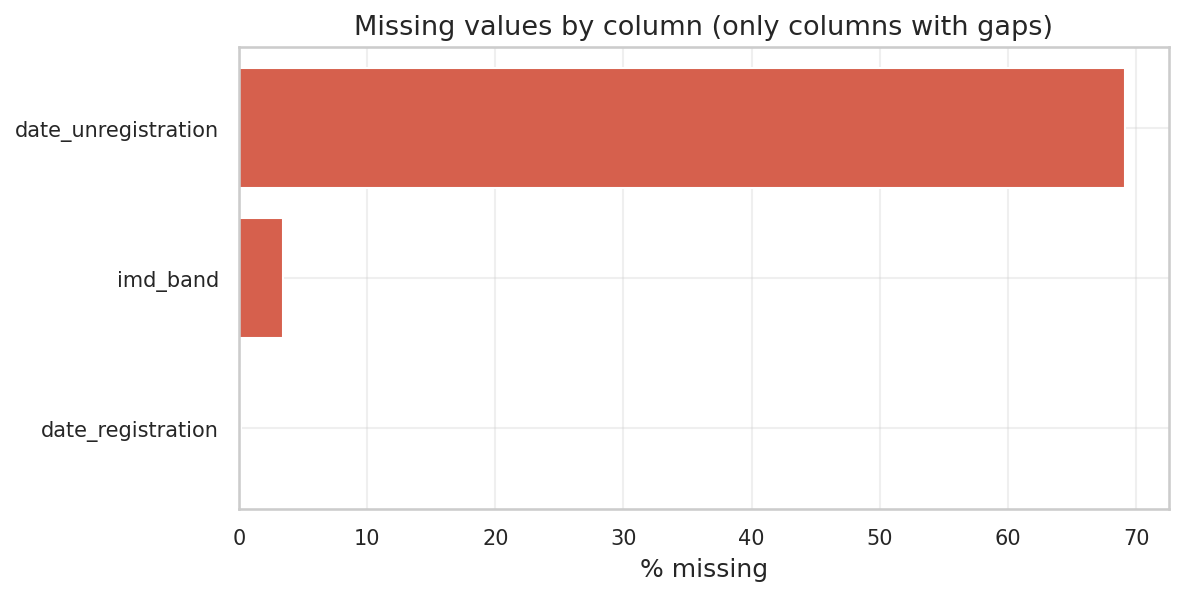

In [3]:
q = eda.data_quality(master)
print(json.dumps(q, indent=2, ensure_ascii=False))
display(pd.DataFrame.from_dict(q['columns_with_missing'], orient='index',
        columns=['số_thiếu']))
display(Image(filename=str(FIGS / 'quality_missingness.png')))

## 2. Phân tích từng biến — Univariate  *(Slide 19)*

**Làm gì:** histogram + KDE và boxplot cho mỗi biến số.

**Vì sao:** phần lớn biến click **lệch phải rất mạnh** — đuôi nặng là ngoại lai *thật* (hành vi học thật), nên không xóa mà biến đổi `log1p`.

**Kết quả:** `clicks_resource` có **skew ≈ 34,7**, **kurtosis ≈ 2.125** — bằng chứng thực nghiệm cho `log1p`; và vì dữ liệu không chuẩn nên các bước sau dùng **kiểm định phi tham số Mann–Whitney**.

In [4]:
uni = eda.univariate(master)
num = pd.read_csv(TABLES / 'univariate_numeric.csv', index_col=0)
print('clicks_resource  -> skew = {:.2f} | kurtosis = {:.2f}'.format(
      num.loc['clicks_resource','skew'], num.loc['clicks_resource','kurtosis']))
print('5 biến lệch nhất:', json.dumps(uni['most_skewed'], ensure_ascii=False))
display(num[['mean','std','min','50%','max','skew','kurtosis']])

clicks_resource  -> skew = 34.71 | kurtosis = 2125.45
5 biến lệch nhất: {"clicks_resource": 34.71, "clicks_url": 13.1, "max_clicks_single_day": 10.56, "clicks_oucollaborate": 7.83, "clicks_forumng": 7.33}


,mean,std,min,50%,max,skew,kurtosis
num_of_prev_attempts,0.163,0.480,0.0,0.0,6.0,3.808,19.432
studied_credits,79.759,41.072,30.0,60.0,655.0,1.876,7.738
date_registration,-69.411,49.261,-322.0,-57.0,167.0,-1.008,1.002
total_clicks,1215.141,1692.604,0.0,602.0,24139.0,3.028,14.950
n_days_active,55.476,54.515,0.0,40.0,286.0,1.175,0.946
max_clicks_single_day,109.856,142.907,0.0,74.0,6988.0,10.559,320.178
mean_clicks_per_active_day,17.076,12.400,0.0,15.0,221.2,1.556,7.470
days_since_last_activity,97.020,100.631,0.0,34.0,292.0,0.574,-1.372
clicks_forumng,244.635,572.035,0.0,68.0,13154.0,7.326,83.332
clicks_oucontent,343.841,633.447,0.0,73.0,9308.0,3.504,18.795


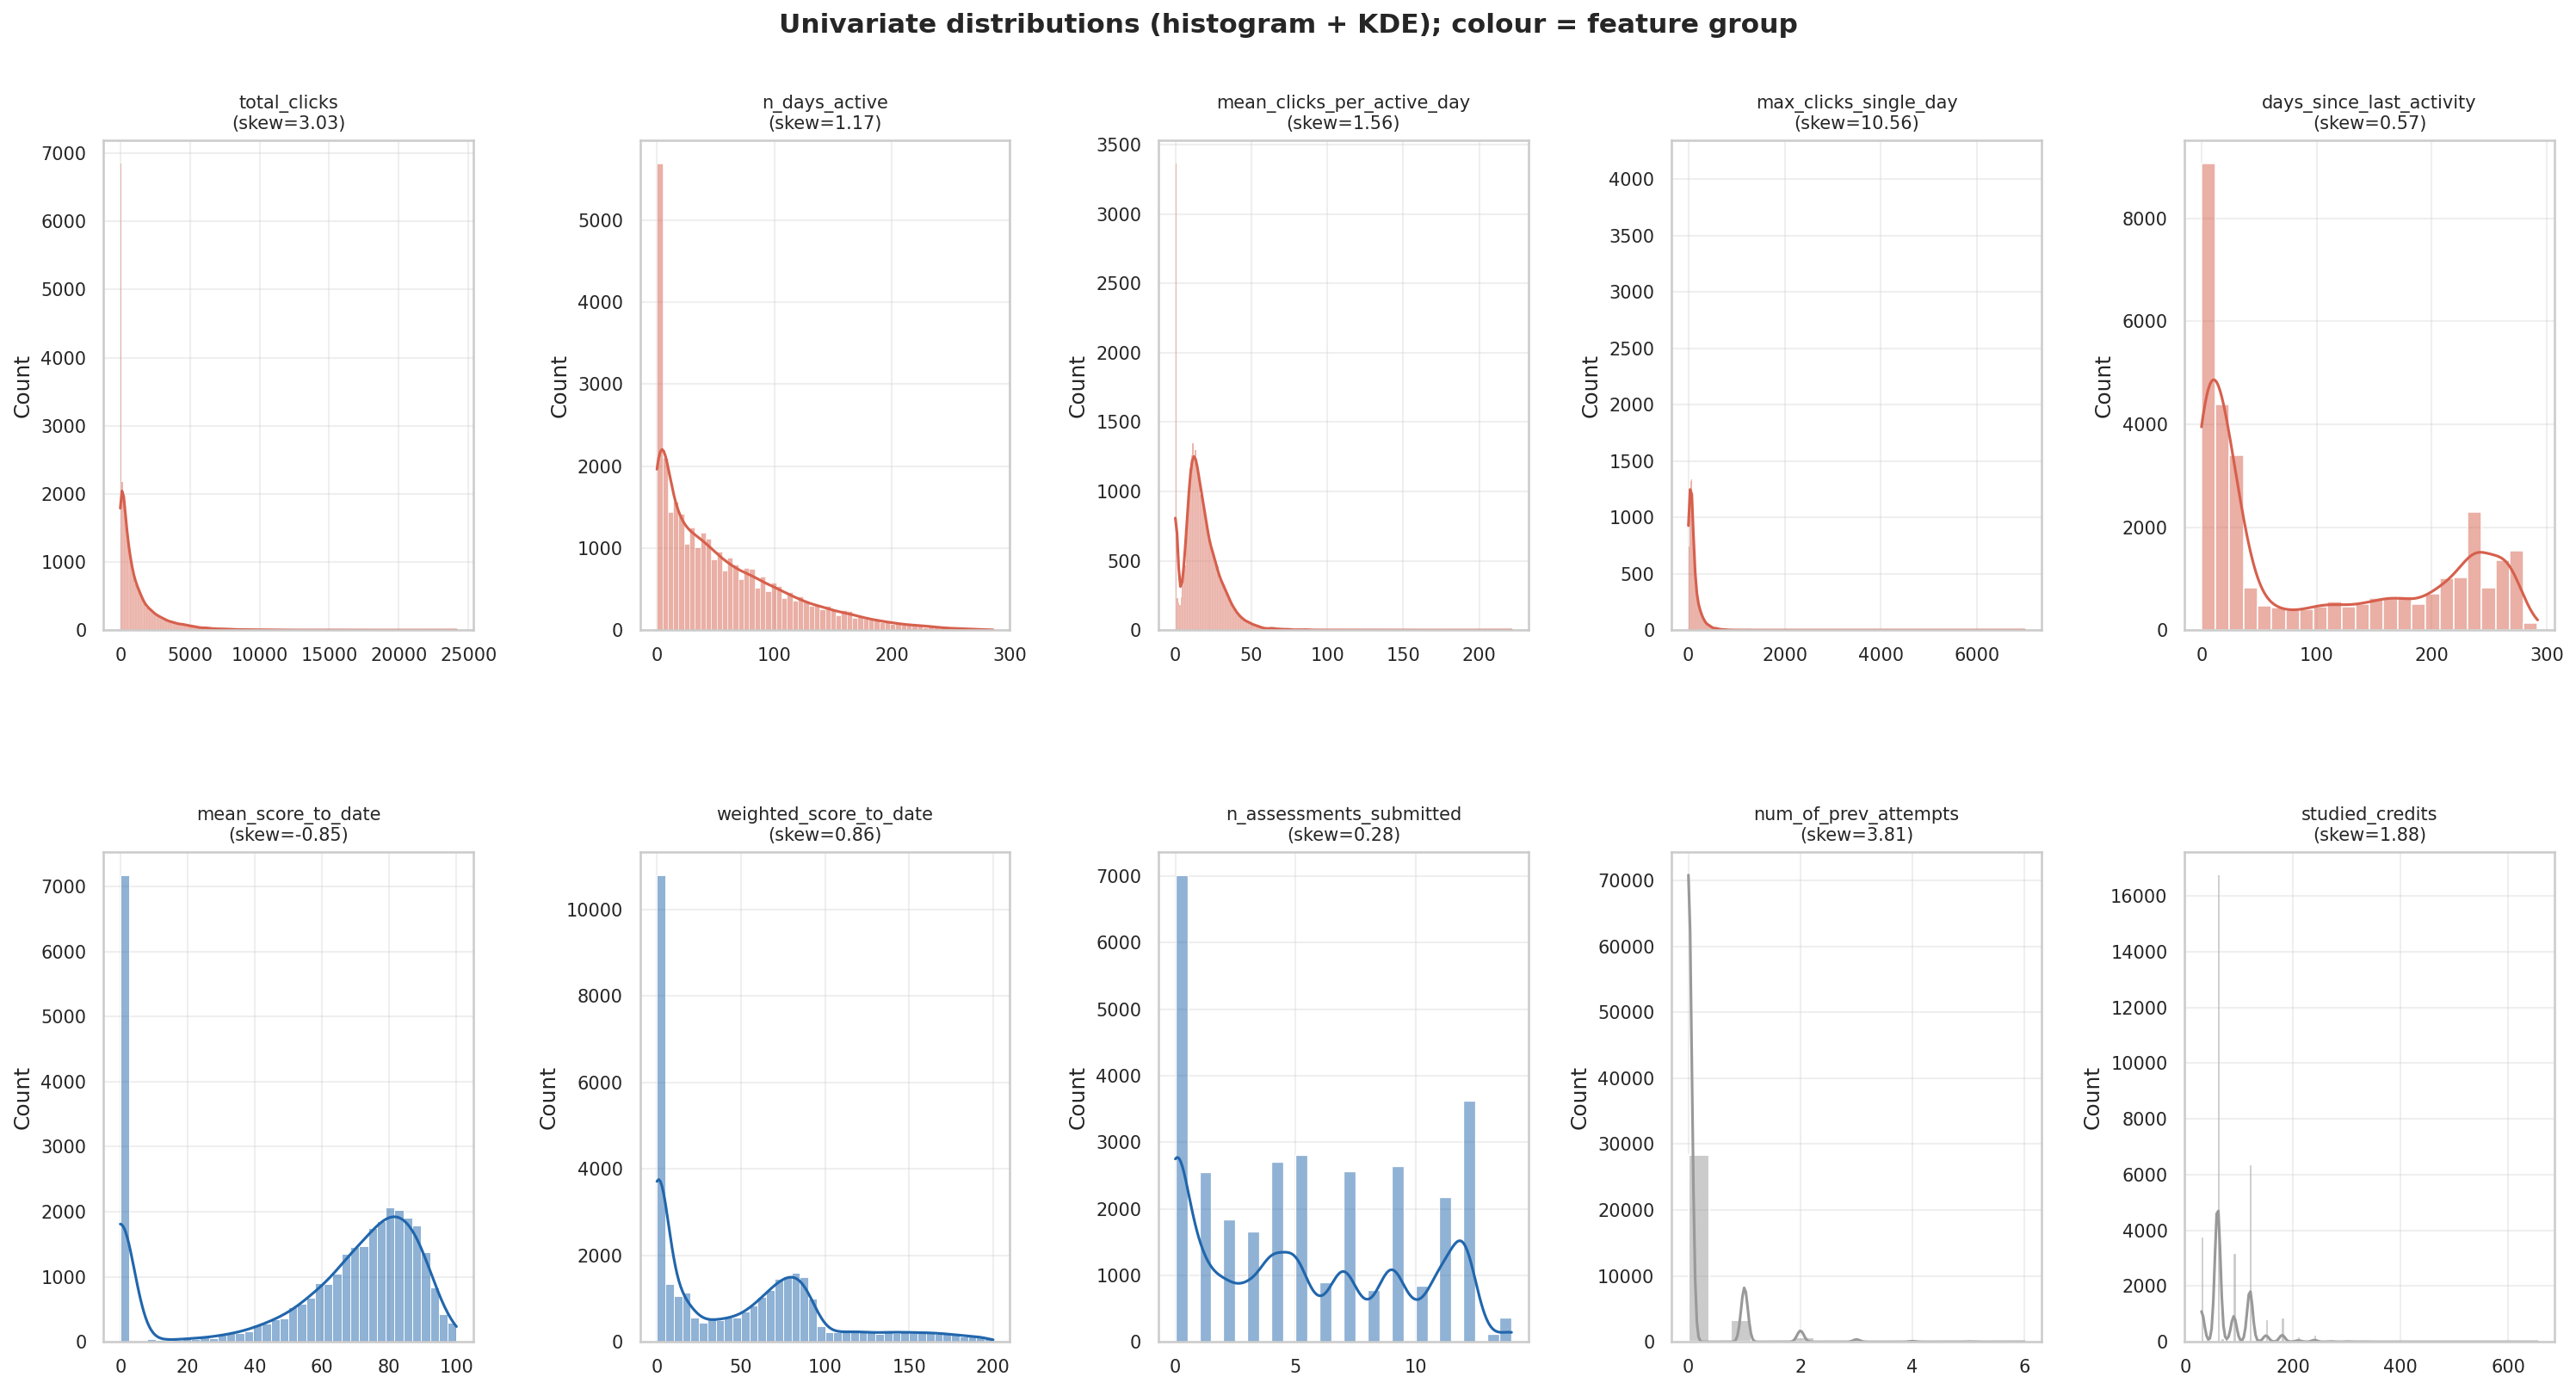

In [5]:
display(Image(filename=str(FIGS / 'univariate_hist_kde.png')))

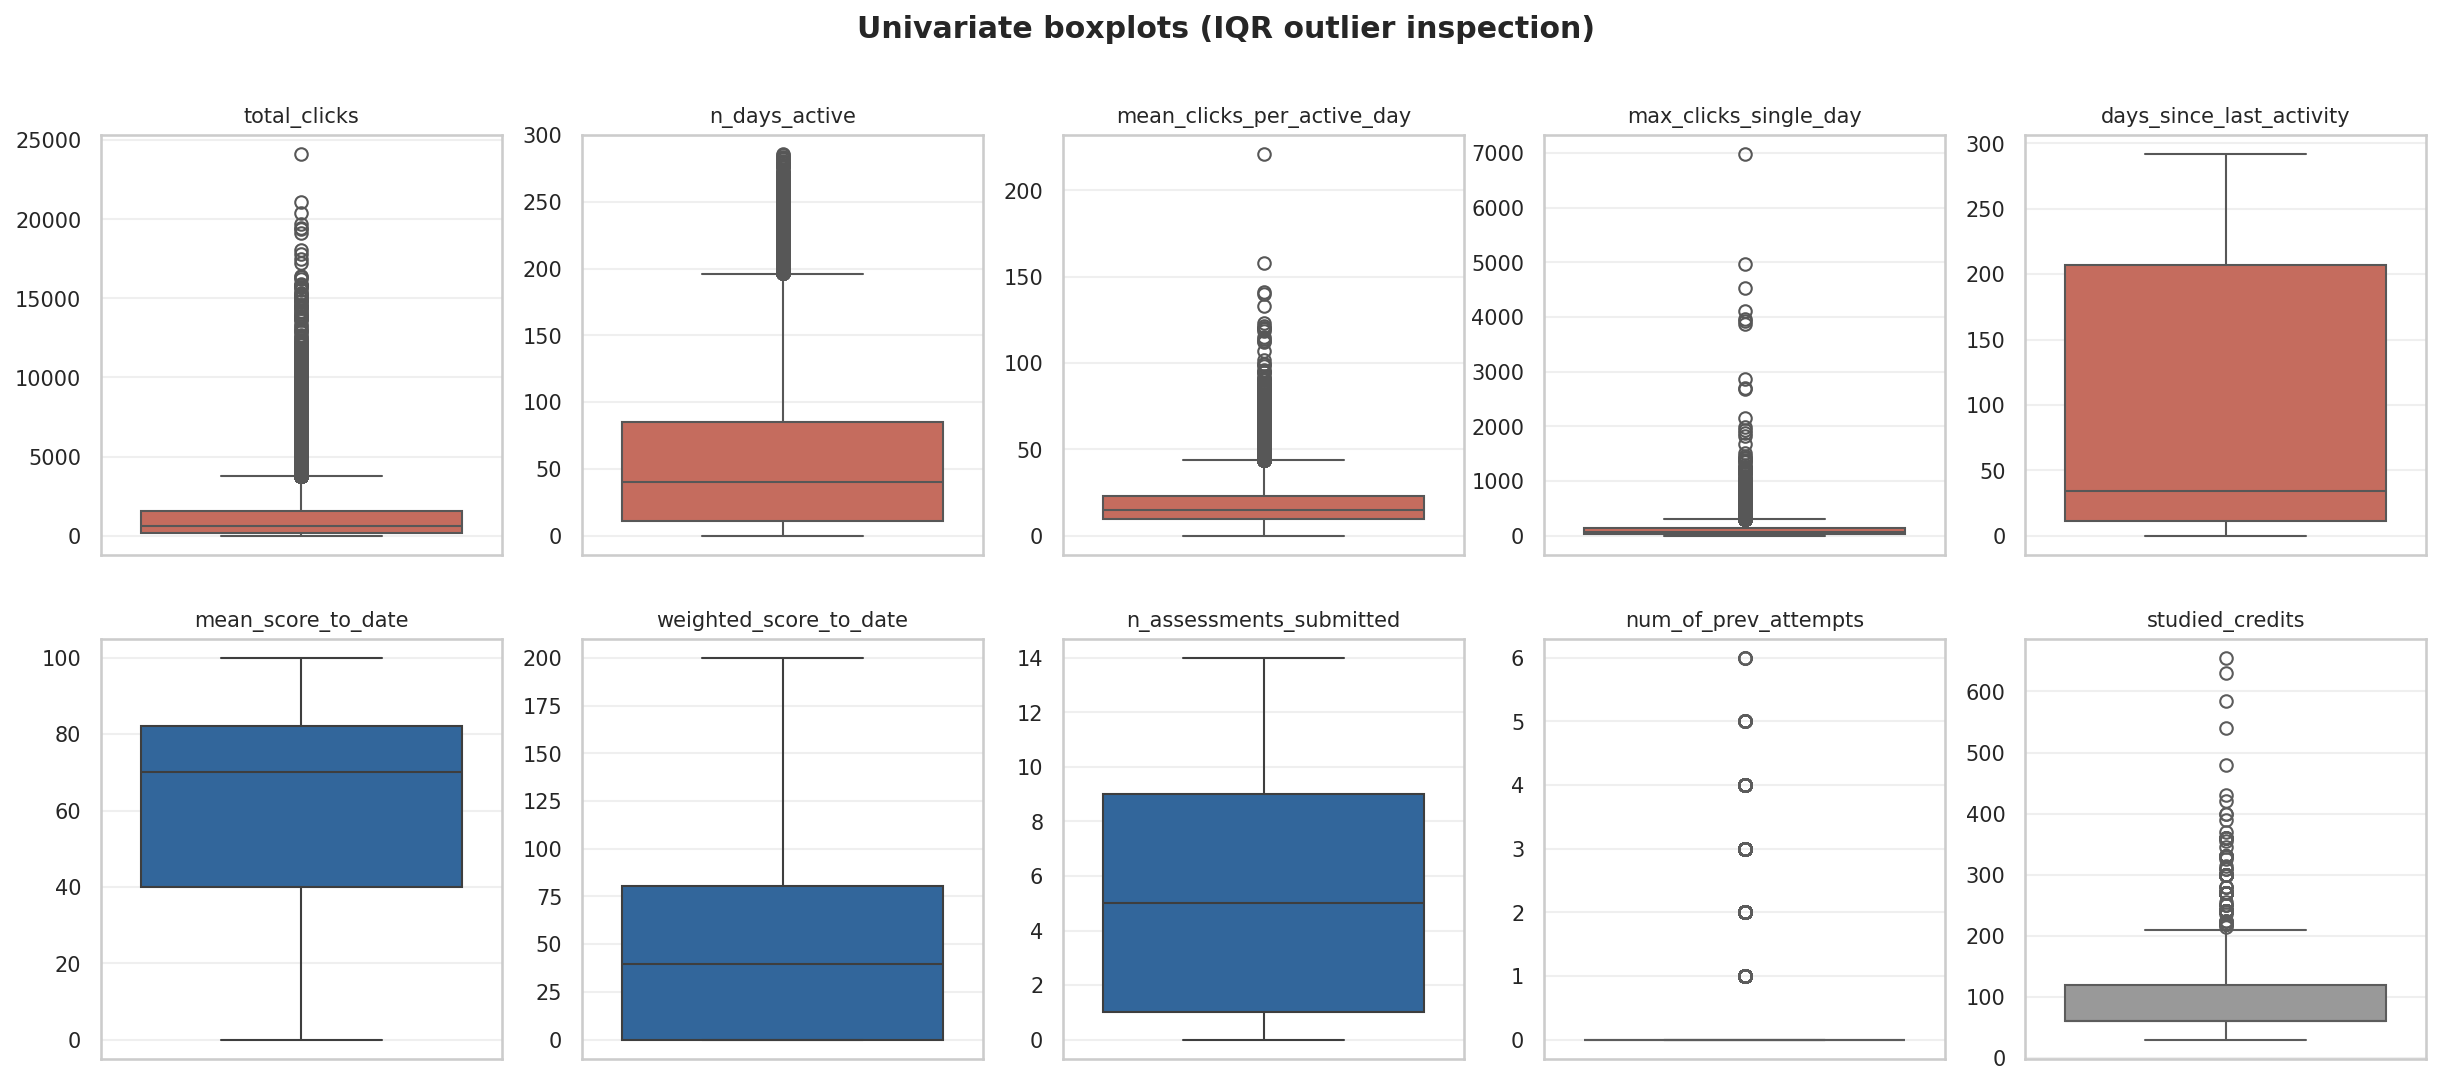

In [6]:
display(Image(filename=str(FIGS / 'univariate_boxplots.png')))

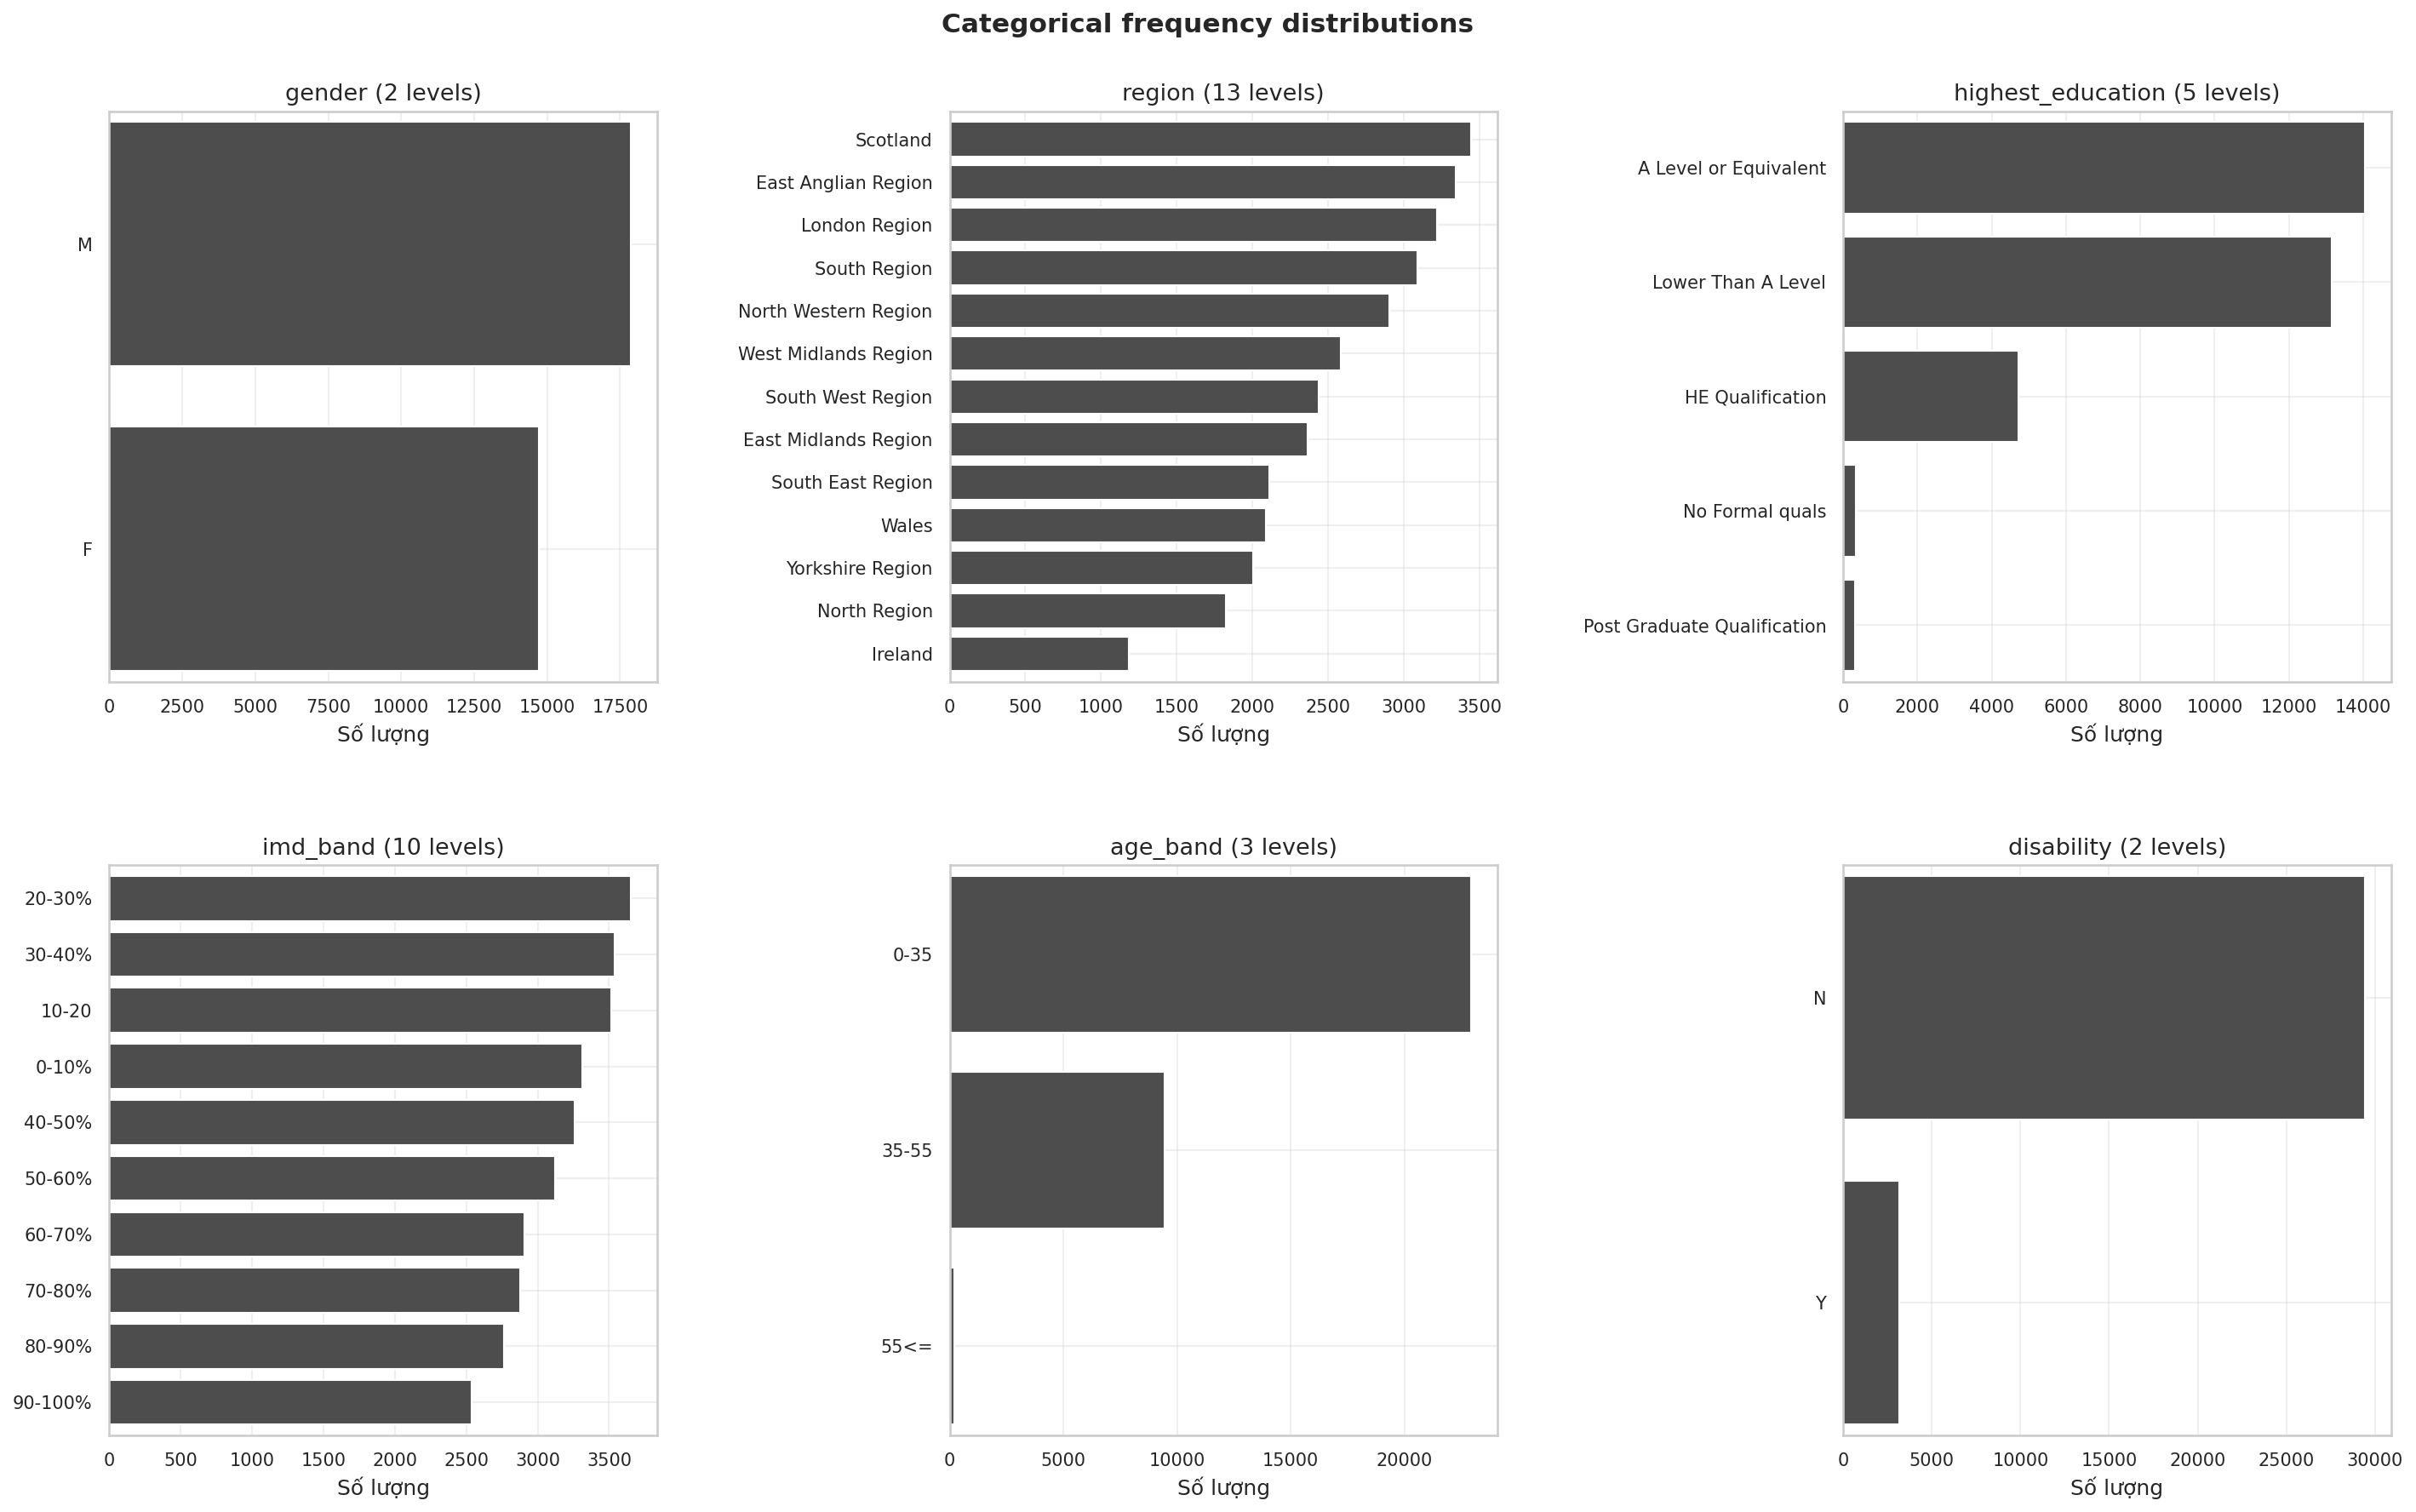

In [7]:
display(Image(filename=str(FIGS / 'univariate_categorical_freq.png')))

## 3. Phân phối lớp & mất cân bằng  *(Slide 20)*

Tỉ lệ at-risk quan sát được là **52,8%** (tỉ số mất cân bằng **1,12**) — đa số *nhẹ*, là số thật của bộ dữ liệu chứ không phải 68/32. Vì bỏ sót sinh viên nguy cơ là sai lầm đắt nhất, chỉ số chính là **PR-AUC & recall** lớp at-risk.

{
  "final_result_counts": {
    "Pass": 12361,
    "Withdrawn": 10156,
    "Fail": 7052,
    "Distinction": 3024
  },
  "at_risk_rate": 0.528,
  "imbalance_ratio": 1.118
}


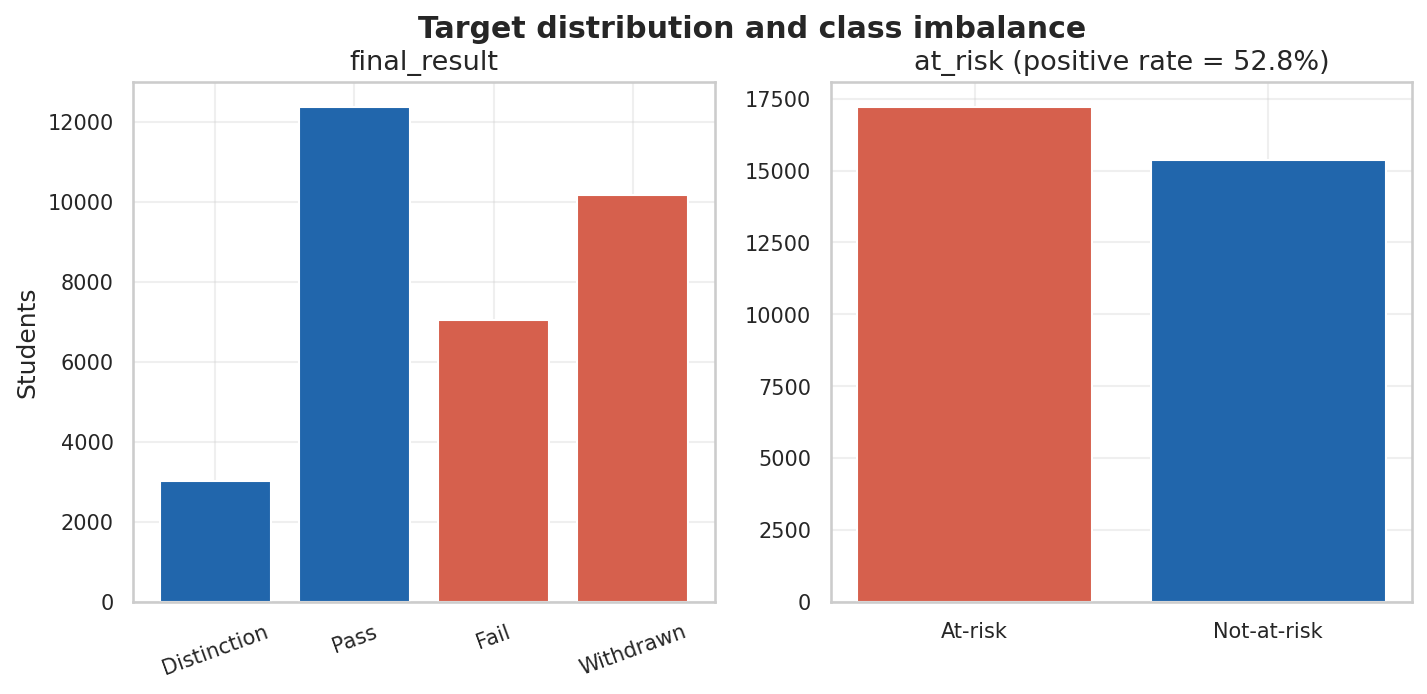

In [8]:
td = eda.target_distribution(master)
print(json.dumps(td, indent=2, ensure_ascii=False))
display(Image(filename=str(FIGS / 'target_distribution.png')))

## 4. Biến số theo nhãn — Bivariate  *(Slide 20)*

**Làm gì:** với mỗi biến số, đo **Cohen's d** + kiểm định **Mann–Whitney** (hiệu chỉnh Benjamini–Hochberg).

**Vì sao:** ở n≈32k, p-value gần như luôn nhỏ → **xếp hạng bằng độ lớn hiệu ứng**, không bằng p.

**Kết quả:** ba biến mạnh nhất thuộc tương tác & điểm — `days_since_last_activity` **d=2,55** (171 vs 14 ngày), `n_assessments_submitted` **2,05** (2,3 vs 8,6 bài), `weighted_score_to_date` **1,96**. **19/19 biến có ý nghĩa** → tín hiệu nằm ở hành vi & điểm, không phải nhân khẩu học.

In [9]:
bv = eda.numeric_vs_target(master)
tb = pd.read_csv(TABLES / 'bivariate_numeric_tests.csv')
top5 = tb.sort_values('cohens_d', ascending=False).head(5)
display(top5[['feature','group','mean_not_at_risk','mean_at_risk','cohens_d','p_adj_bh']])
r = tb.set_index('feature')
print('days_since_last_activity: at-risk {:.0f} ngày  vs  not-at-risk {:.0f} ngày'.format(
      r.loc['days_since_last_activity','mean_at_risk'], r.loc['days_since_last_activity','mean_not_at_risk']))
print('n_assessments_submitted : at-risk {:.1f} bài   vs  not-at-risk {:.1f} bài'.format(
      r.loc['n_assessments_submitted','mean_at_risk'], r.loc['n_assessments_submitted','mean_not_at_risk']))
print('Số biến có ý nghĩa (q<0.05): {}/{}'.format(bv['n_significant'], bv['n_tested']))

,feature,group,mean_not_at_risk,mean_at_risk,cohens_d,p_adj_bh
0,days_since_last_activity,Engagement,14.215,171.053,2.546,0.0
1,n_assessments_submitted,Performance,8.560,2.337,2.054,0.0
2,weighted_score_to_date,Performance,84.862,15.132,1.964,0.0
3,n_days_active,Engagement,91.565,23.210,1.584,0.0
4,mean_score_to_date,Performance,78.514,37.819,1.578,0.0


days_since_last_activity: at-risk 171 ngày  vs  not-at-risk 14 ngày
n_assessments_submitted : at-risk 2.3 bài   vs  not-at-risk 8.6 bài
Số biến có ý nghĩa (q<0.05): 19/19


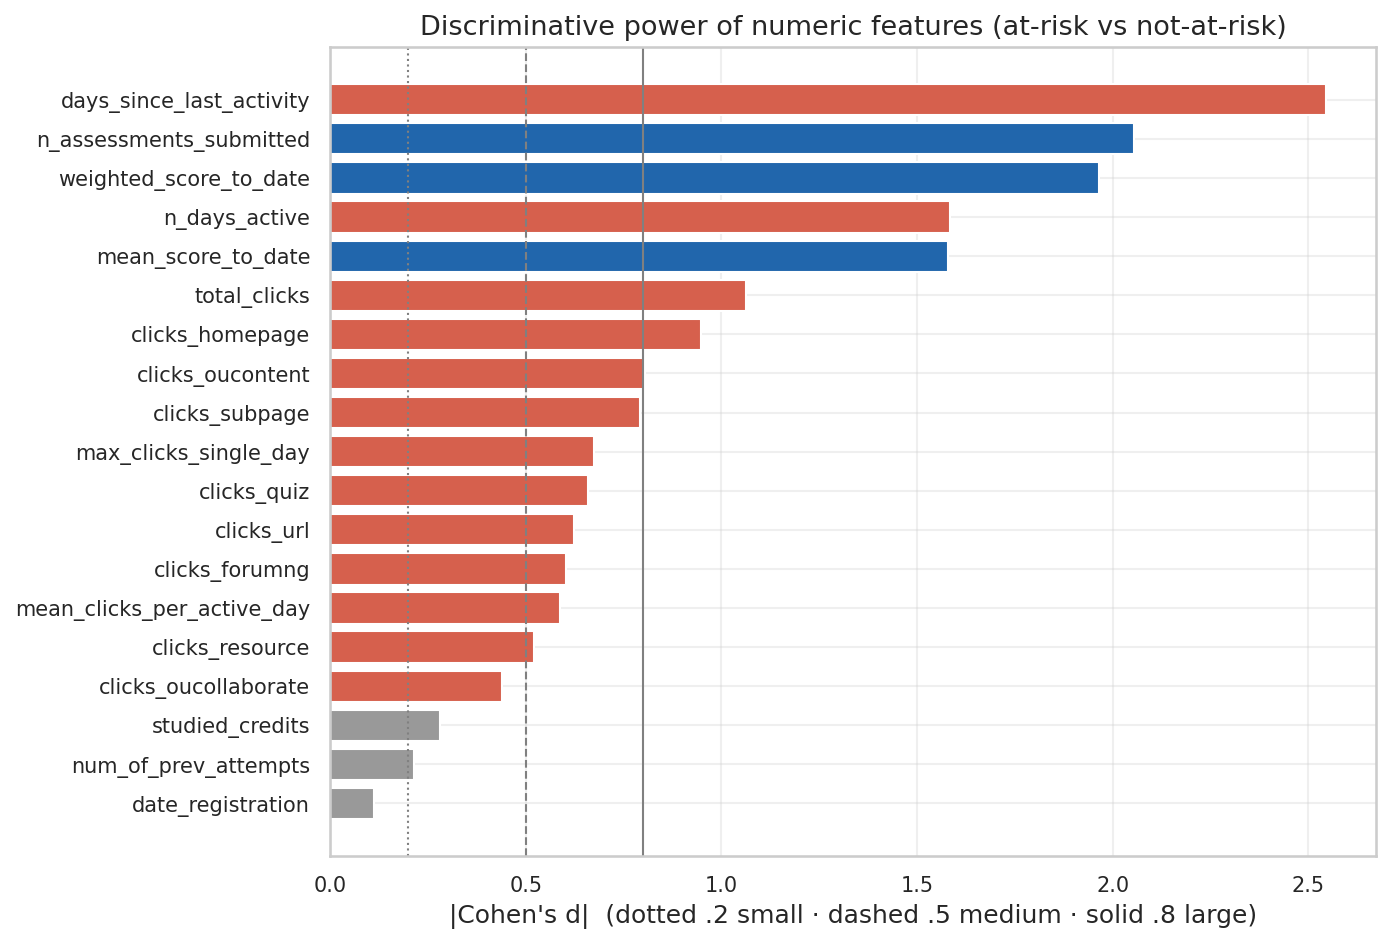

In [10]:
display(Image(filename=str(FIGS / 'bivariate_effect_sizes.png')))

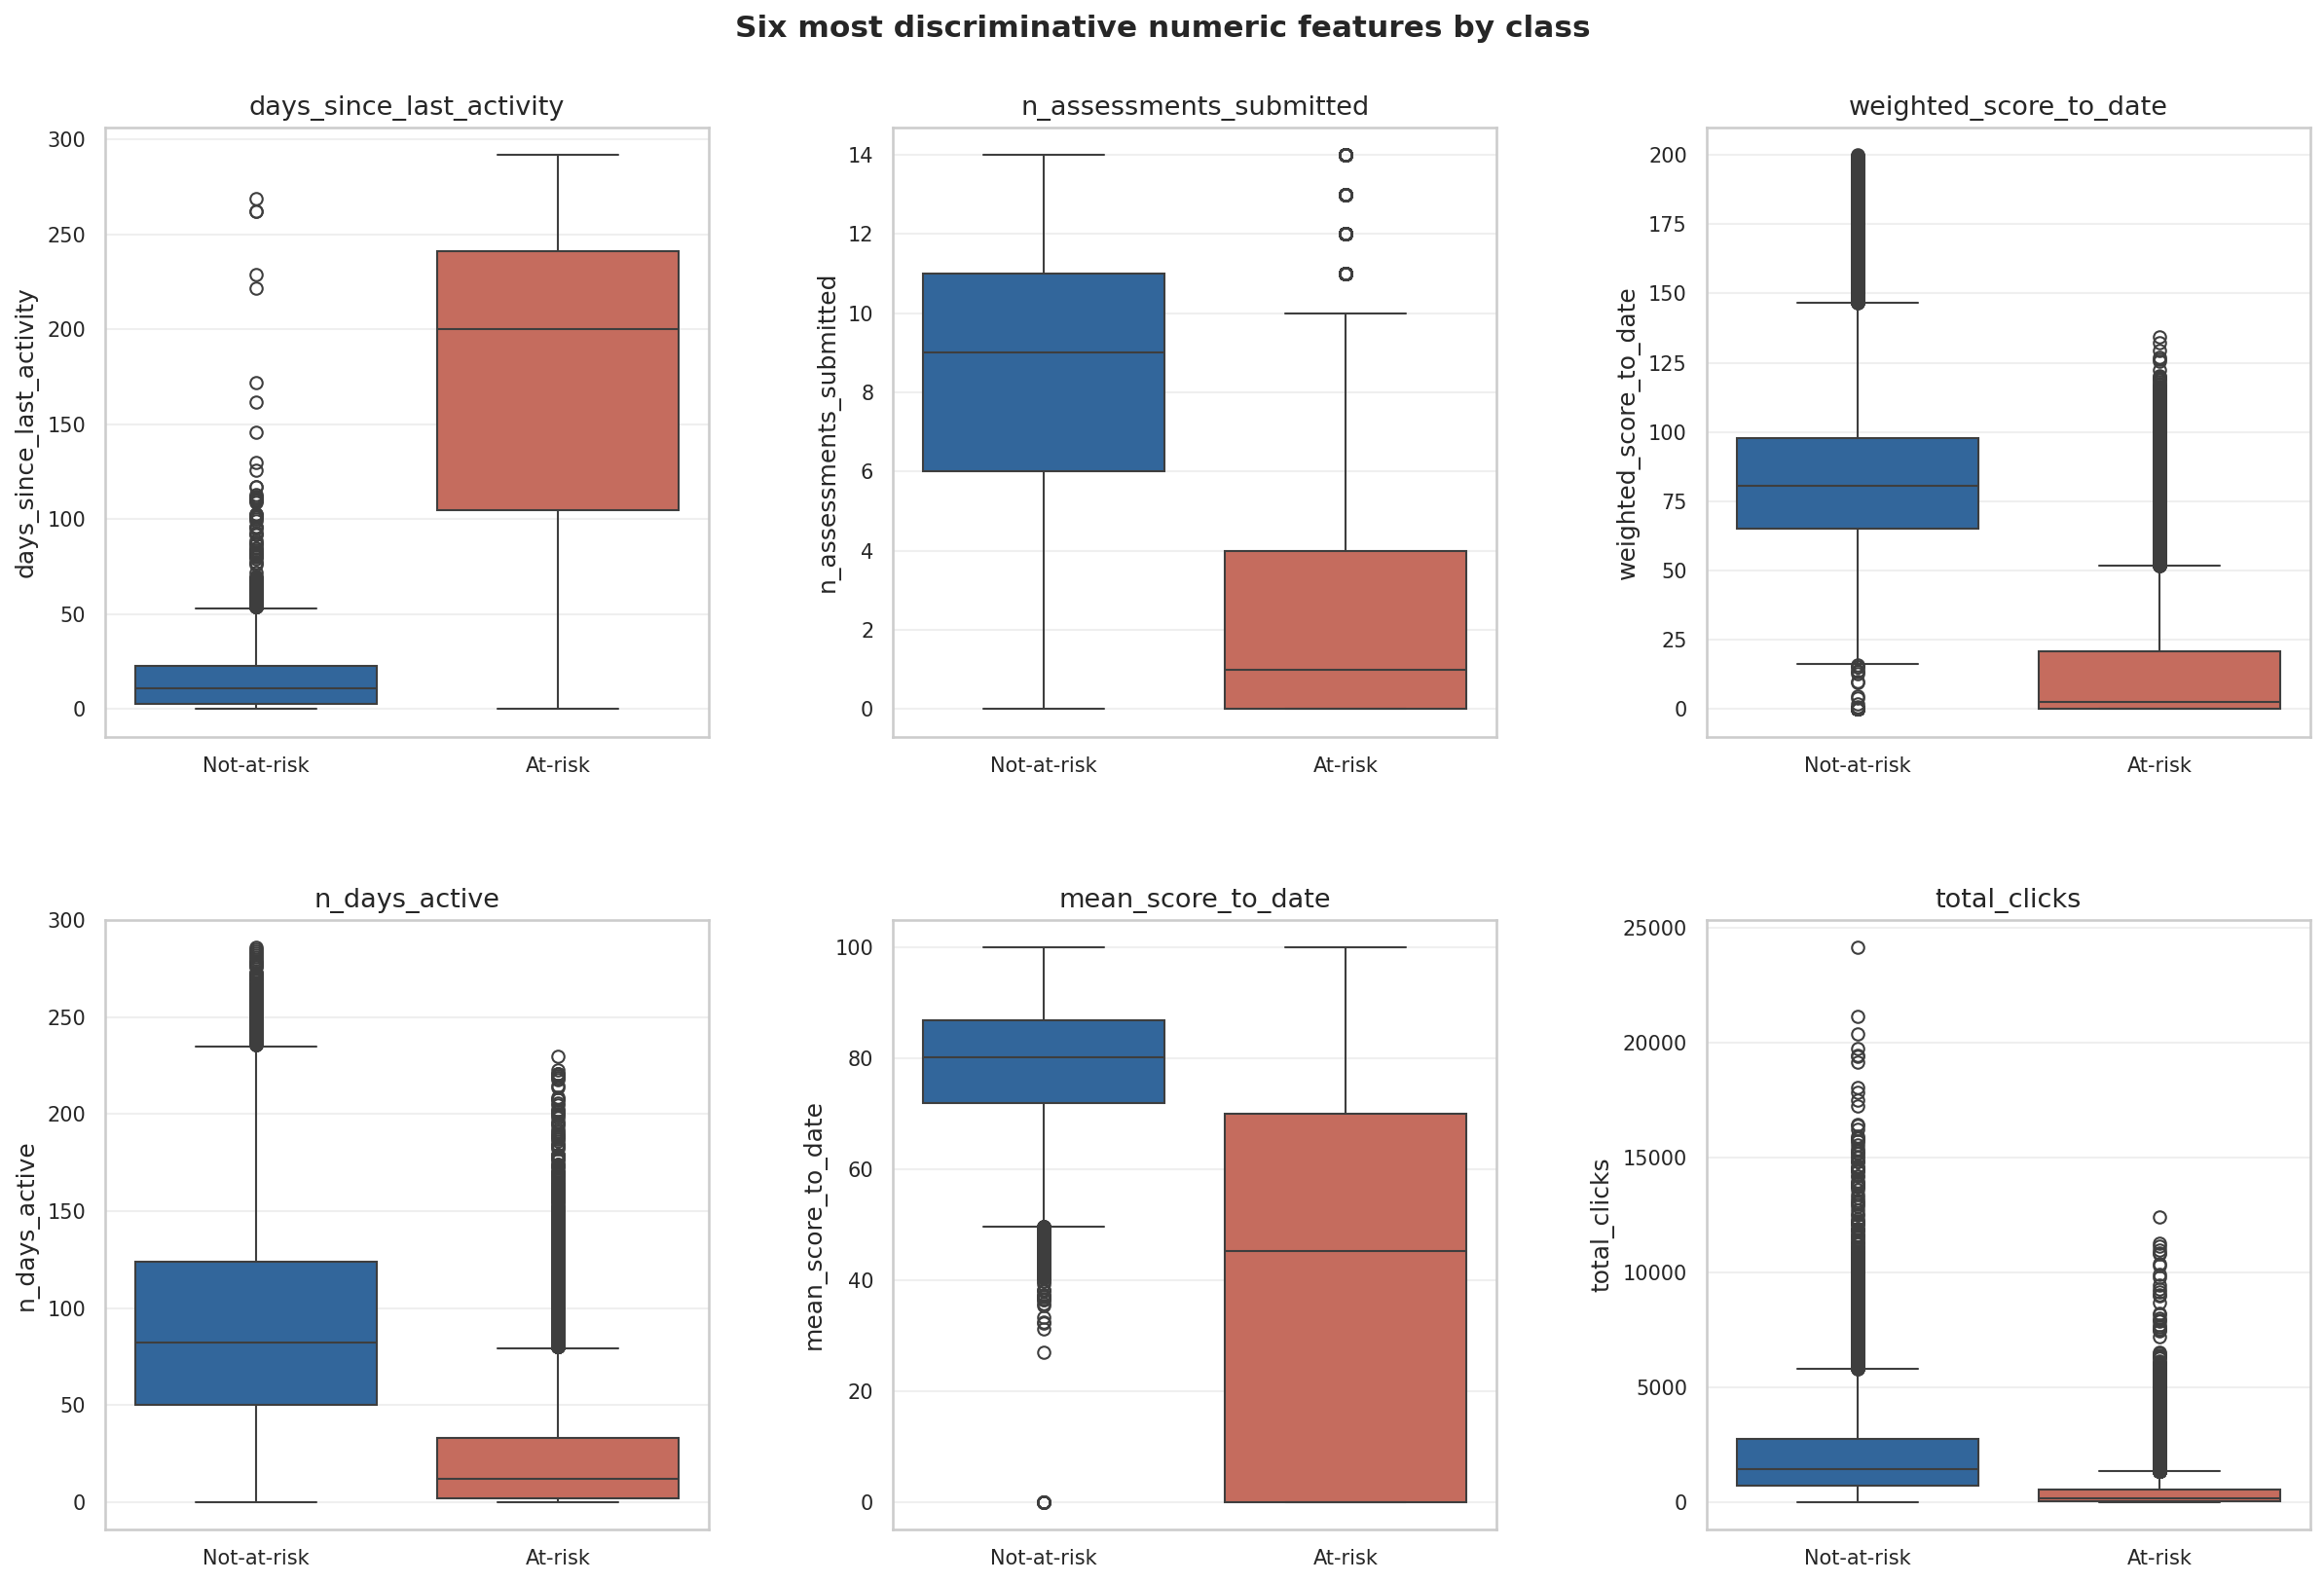

In [11]:
display(Image(filename=str(FIGS / 'bivariate_top_boxplots.png')))

## 5. Biến phân loại theo nhãn  *(Slide 20 — phần phụ)*

Chi-square có ý nghĩa nhưng **Cramér's V** đều nhỏ: `highest_education` (0,15) và `imd_band` (0,15) dẫn đầu, `gender` (0,02) gần như không đáng kể → nhân khẩu học mang tín hiệu độc lập hạn chế, **giữ để phân tích công bằng** hơn là để dự đoán.

{
  "association_cramers_v": {
    "highest_education": 0.15,
    "imd_band": 0.149,
    "region": 0.081,
    "age_band": 0.069,
    "disability": 0.059,
    "gender": 0.022
  }
}


,feature,chi2,dof,p_value,cramers_v
0,highest_education,737.25,4,2.999038e-158,0.150
1,imd_band,721.97,10,1.204290e-148,0.149
2,region,213.74,12,4.709358e-39,0.081
3,age_band,154.22,2,3.244822e-34,0.069
4,disability,114.90,1,8.286448e-27,0.059
5,gender,16.30,1,5.392941e-05,0.022


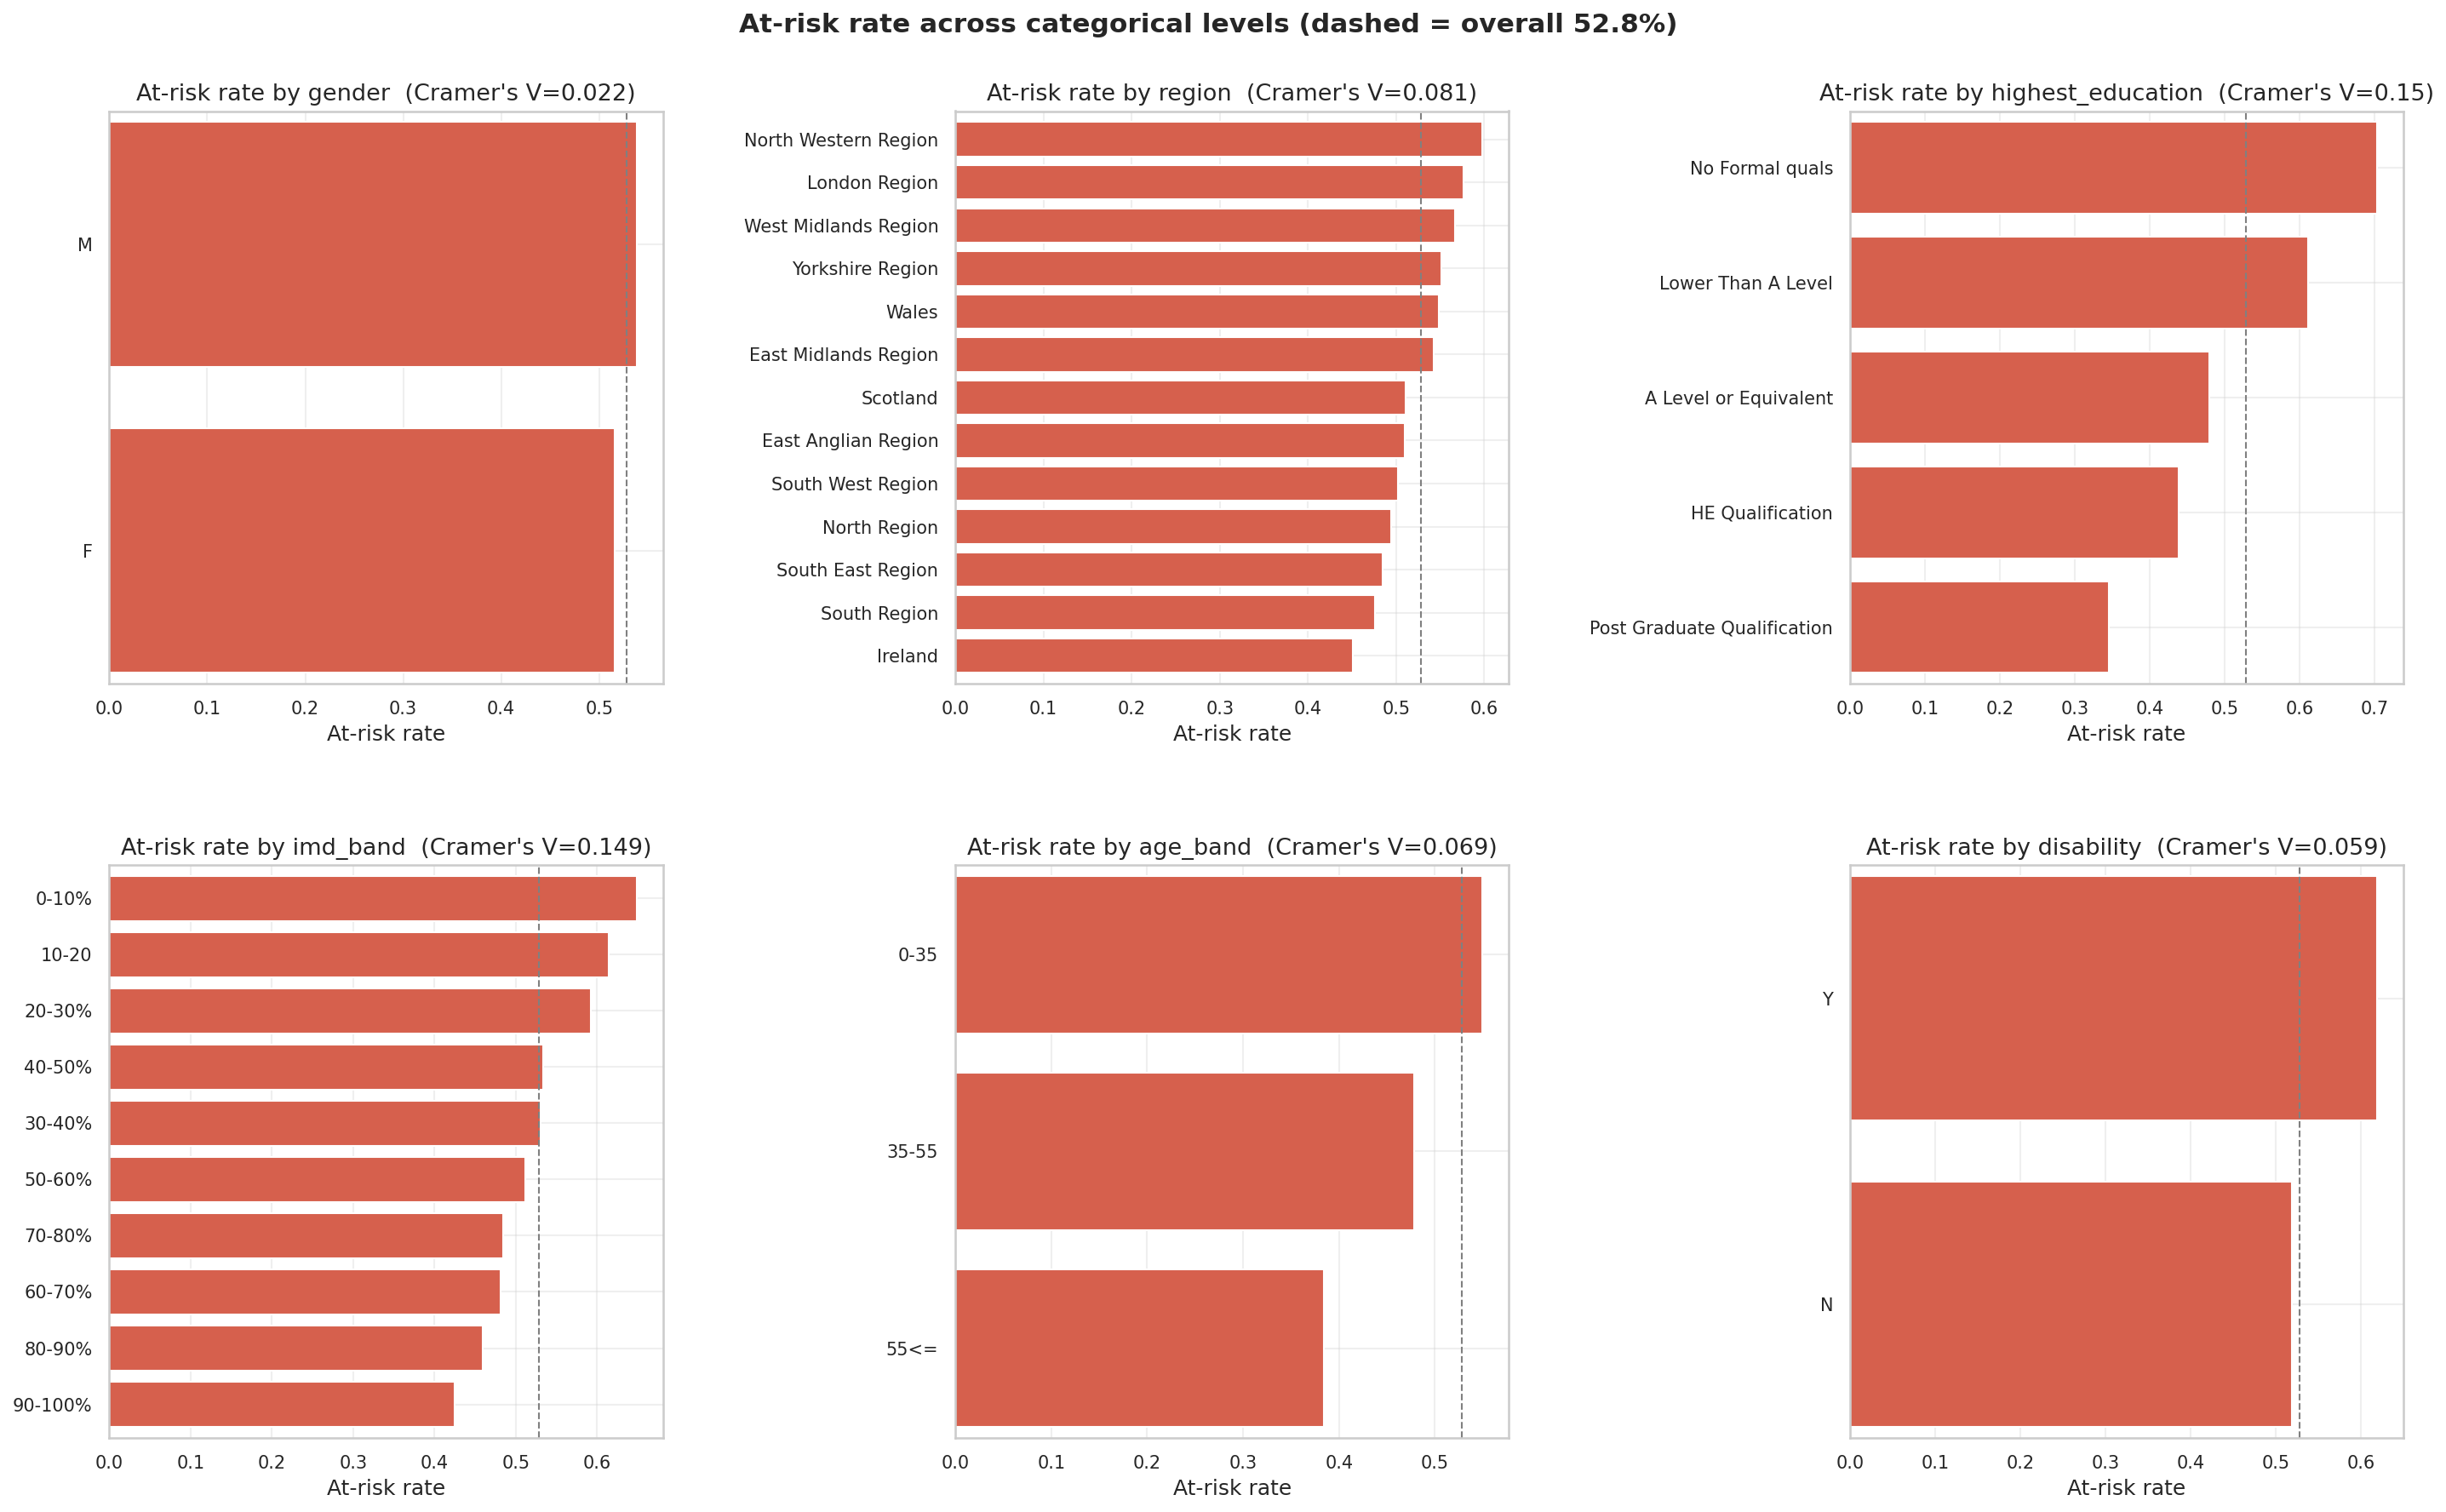

In [12]:
cv = eda.categorical_vs_target(master)
print(json.dumps(cv, indent=2, ensure_ascii=False))
display(pd.read_csv(TABLES / 'bivariate_categorical_tests.csv'))
display(Image(filename=str(FIGS / 'bivariate_categorical_rate.png')))

## 6. Tương quan, đa cộng tuyến & kiểm tra rò rỉ — Multivariate  *(Slide 21)*

**Làm gì:** ma trận Pearson + Spearman; tương quan với nhãn; kiểm tra rò rỉ.

**Vì sao:** rò rỉ là bước **bắt buộc** — nếu một biến |r| ≥ 0,95 với nhãn thì rất đáng nghi chứa sẵn đáp án.

**Kết quả:** tương quan mạnh nhất với nhãn là `days_since` **+0,78** (khớp Cohen's d → hai phương pháp độc lập, cùng kết luận); **không biến nào |r| ≥ 0,95 → không rò rỉ**; 2 cặp đa cộng tuyến ≥ 0,8 (để dành RQ2).

In [13]:
co = eda.correlation(master)
ct = pd.read_csv(TABLES / 'correlation_with_target.csv', index_col=0)
display(ct)
mx = ct['pearson_r_with_at_risk'].abs().max()
print('Đa cộng tuyến |r|>=0.8:', json.dumps(co['multicollinear_ge_0.8'], ensure_ascii=False))
print('|r| lớn nhất với nhãn = {:.3f}  ->  {}'.format(
      mx, 'KHÔNG rò rỉ (ngưỡng 0.95)' if mx < 0.95 else 'CẢNH BÁO rò rỉ'))
assert mx < 0.95, 'Phát hiện đặc trưng nghi rò rỉ!'
print('Nghi rò rỉ (>=0.95):', co['leakage_suspects_ge_0.95'])

,pearson_r_with_at_risk
days_since_last_activity,0.778
n_assessments_submitted,-0.716
weighted_score_to_date,-0.706
n_days_active,-0.626
mean_score_to_date,-0.610
total_clicks,-0.477
max_clicks_single_day,-0.323
mean_clicks_per_active_day,-0.281
studied_credits,0.139
num_of_prev_attempts,0.105


Đa cộng tuyến |r|>=0.8: [{"a": "n_days_active", "b": "total_clicks", "r": 0.837}, {"a": "days_since_last_activity", "b": "n_assessments_submitted", "r": -0.828}]
|r| lớn nhất với nhãn = 0.778  ->  KHÔNG rò rỉ (ngưỡng 0.95)
Nghi rò rỉ (>=0.95): []


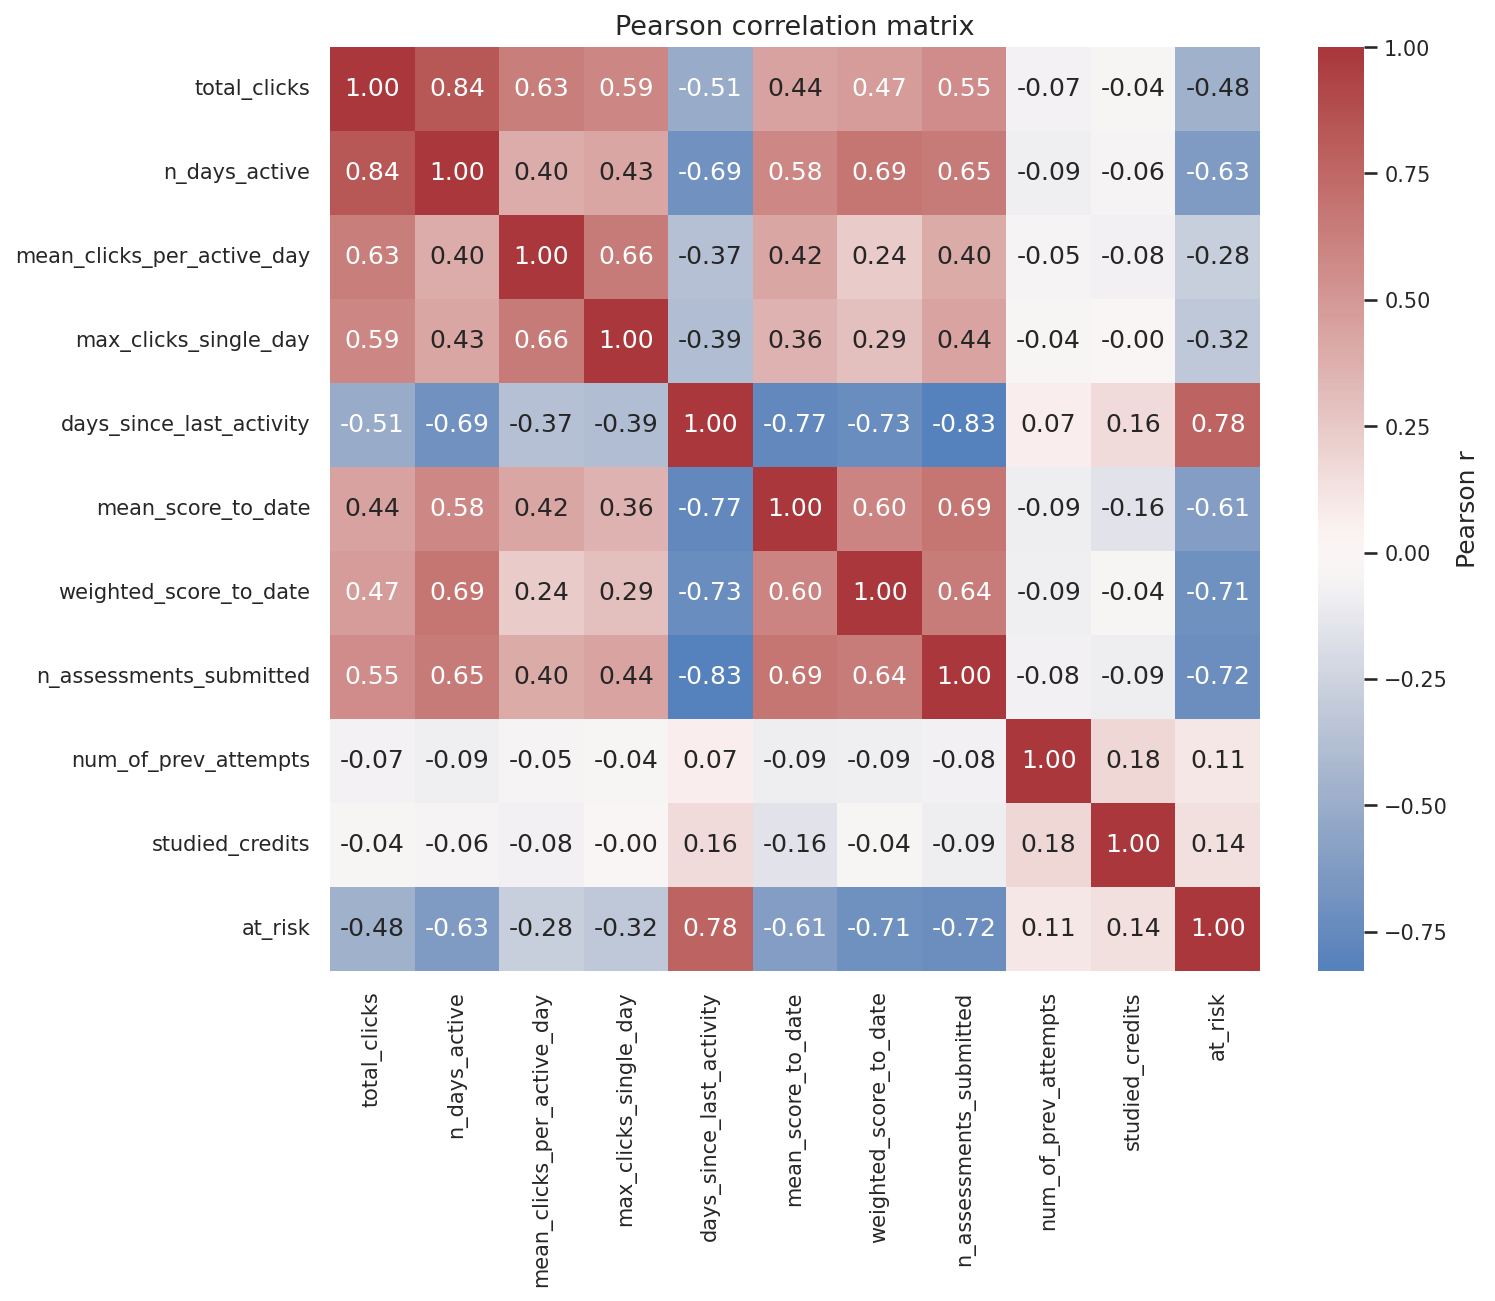

In [14]:
display(Image(filename=str(FIGS / 'corr_pearson.png')))

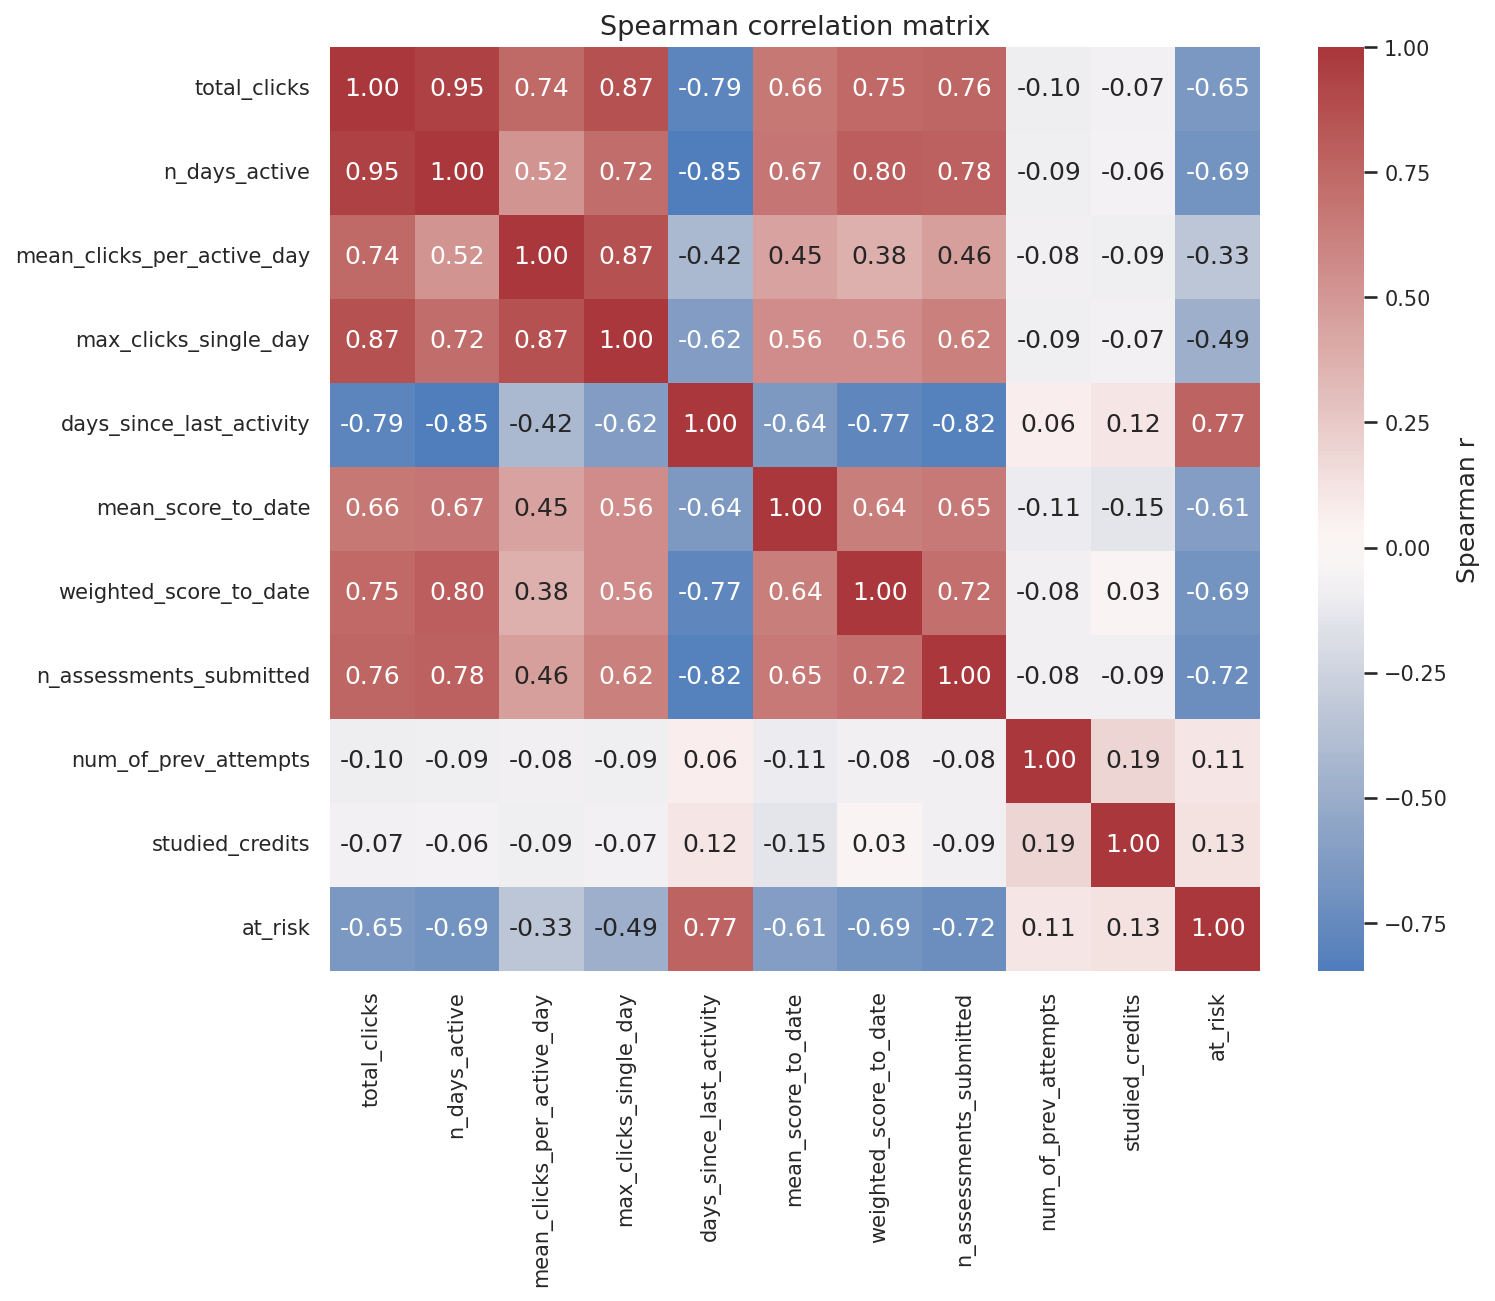

In [15]:
display(Image(filename=str(FIGS / 'corr_spearman.png')))

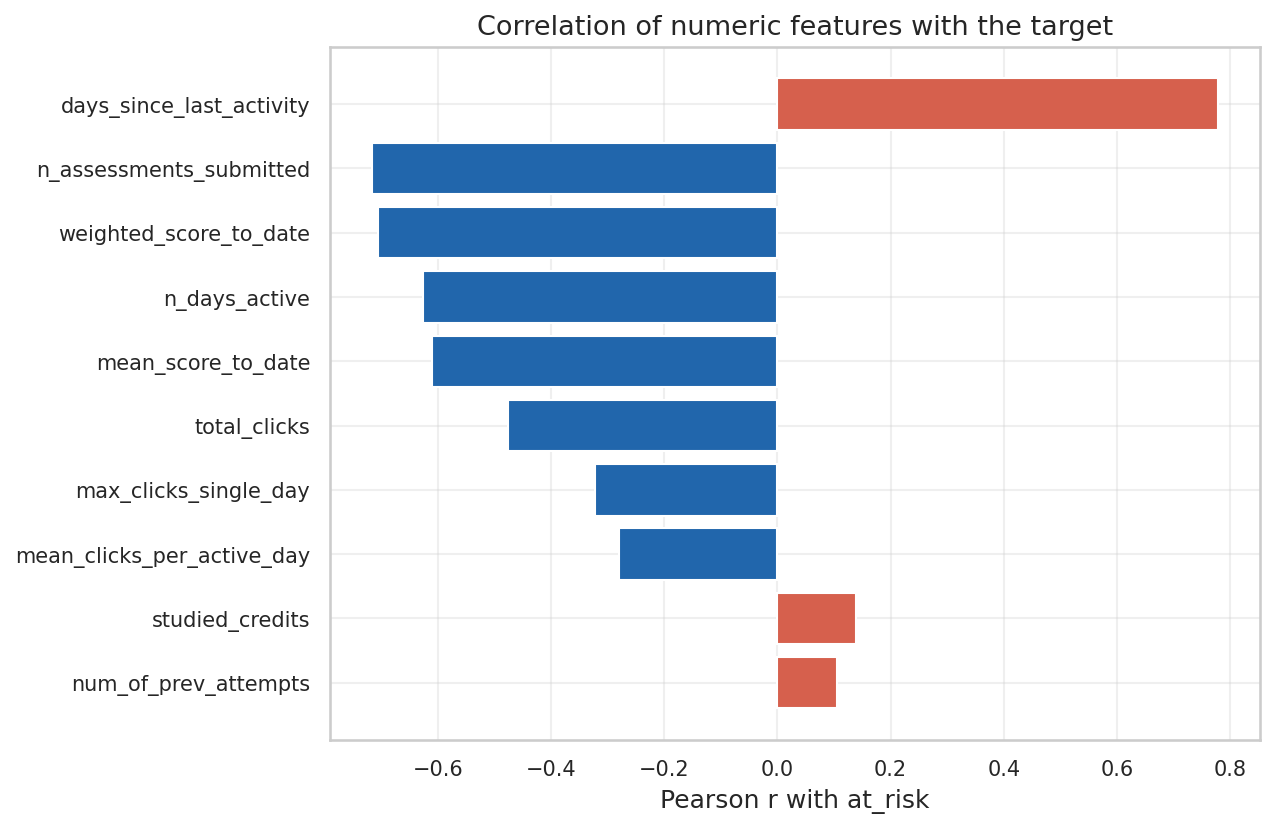

In [16]:
display(Image(filename=str(FIGS / 'corr_with_target.png')))

## 7. Phân tích theo thời gian — khi nào tín hiệu xuất hiện?  *(Slide 22 · RQ1)*

**Làm gì:** đo |Cohen's d| của từng biến tại 6 mốc 10%→100%.

**Vì sao:** đây là phân tích đặc thù của bài toán *time-aware* — xác định mốc sớm nhất đáng tin để dự đoán (RQ1).

**Kết quả:** sức phân biệt **tăng dần đều**; mốc đầu đạt d≥0,8: `n_days_active` từ **10%**, điểm/số bài nộp từ **20%**, `days_since` từ **40%** → **dự đoán sớm khả thi từ ~20% khóa học**.

> ⚠️ Lưu ý nhất quán: d của `days_since` trong bảng theo-mốc (tính trên `dataset_t100`, đã cắt click sau mốc) là **1,56**, khác d=2,55 ở mục 4 (tính trên `master_raw`). Khi thuyết trình hãy trích `weighted_score`/`n_assessments` (khớp tuyệt đối giữa hai bảng) — xem Q&A #6.

In [17]:
ta = eda.time_aware(checkpoints)
disc = pd.read_csv(TABLES / 'discrimination_by_checkpoint.csv', index_col=0)
display(disc)
print('Mốc sớm nhất đạt d>=0.8:')
print(json.dumps(ta['earliest_checkpoint_d_ge_0.8'], indent=2, ensure_ascii=False))

,days_since_last_activity,mean_score_to_date,n_assessments_submitted,n_days_active,total_clicks,weighted_score_to_date
t_percent,,,,,,
10,0.407,0.798,0.669,0.834,0.616,0.606
20,0.688,1.113,0.919,0.991,0.688,1.058
40,1.022,1.492,1.233,1.165,0.780,1.379
60,1.281,1.559,1.652,1.367,0.913,1.820
80,1.495,1.573,1.879,1.500,0.994,2.106
100,1.562,1.578,2.054,1.584,1.064,1.964


Mốc sớm nhất đạt d>=0.8:
{
  "total_clicks": 60,
  "n_days_active": 10,
  "mean_score_to_date": 20,
  "n_assessments_submitted": 20,
  "days_since_last_activity": 40,
  "weighted_score_to_date": 20
}


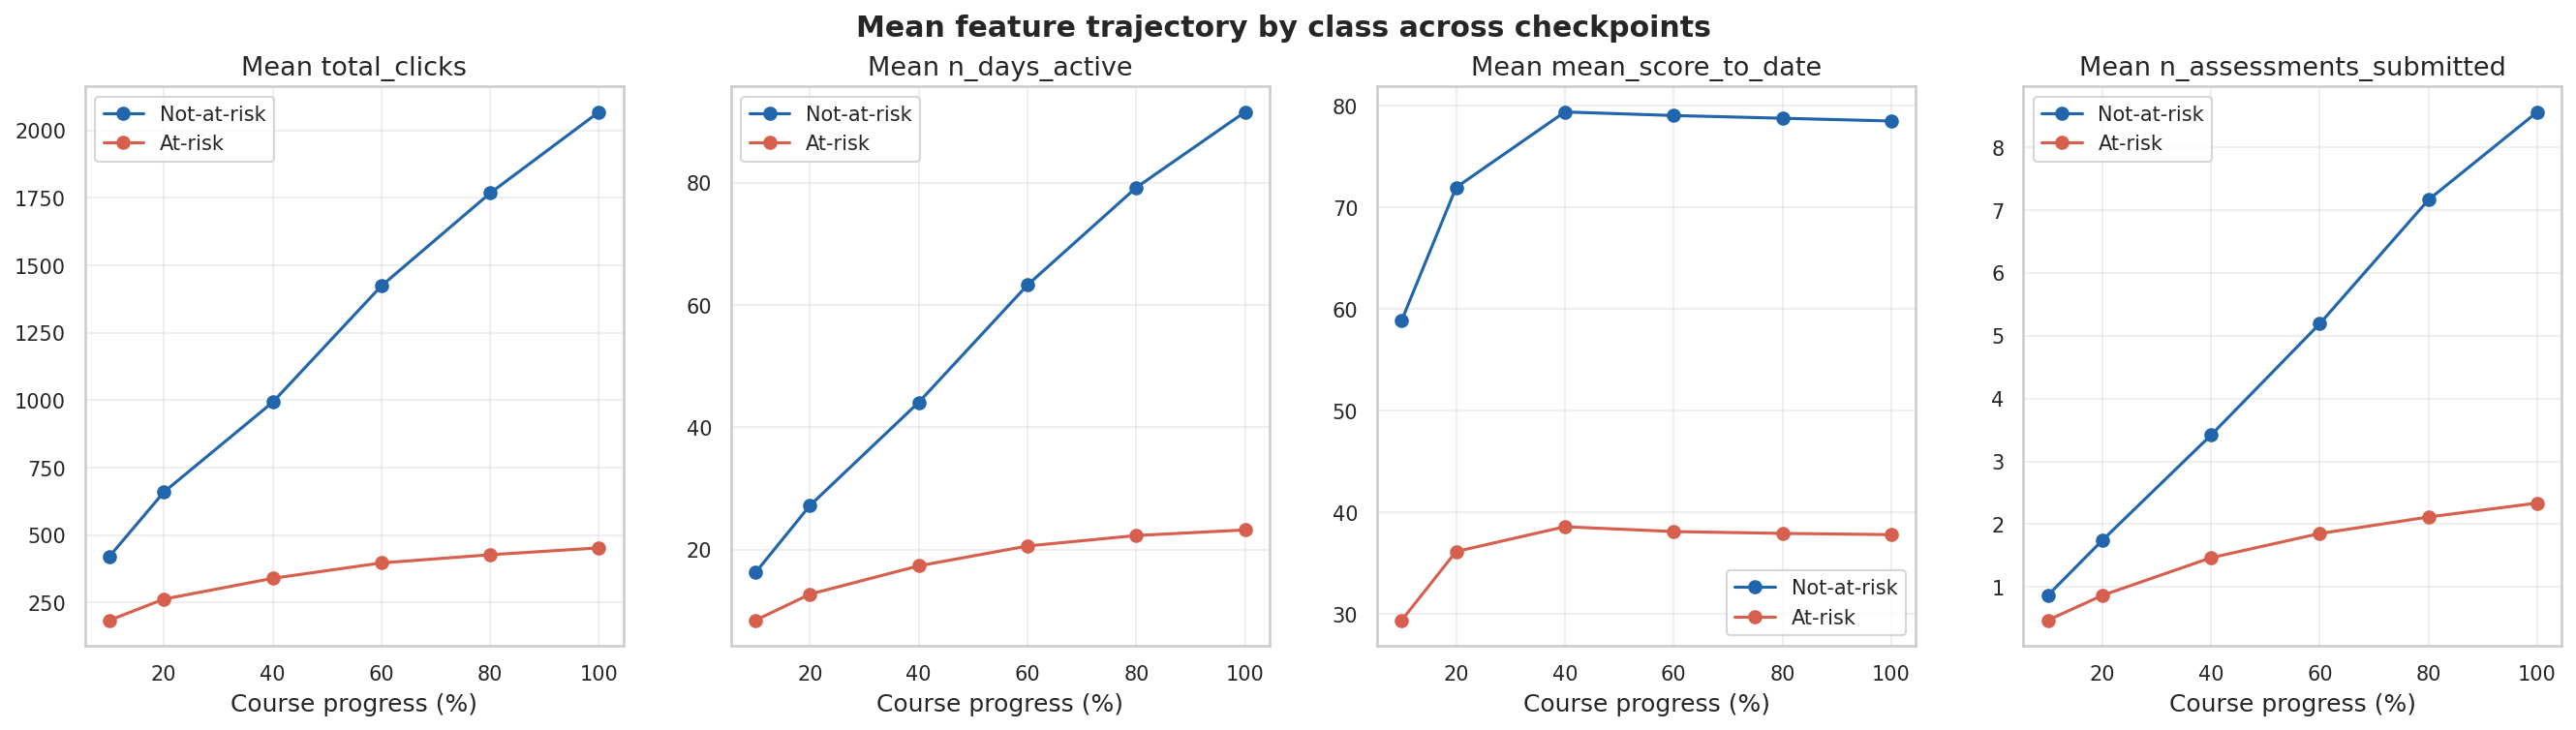

In [18]:
display(Image(filename=str(FIGS / 'time_mean_trajectory.png')))

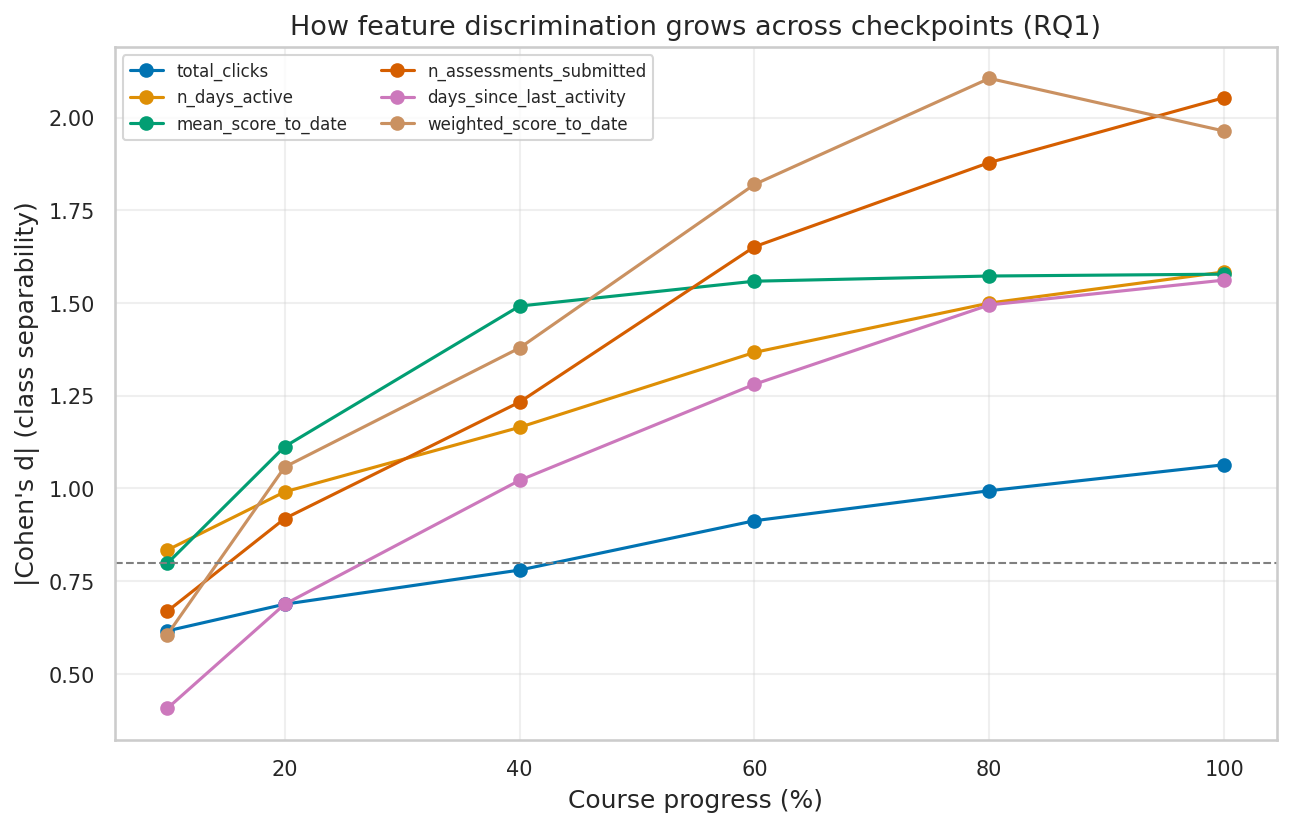

In [19]:
display(Image(filename=str(FIGS / 'time_discrimination_curve.png')))

## 8. Tín hiệu cảnh báo sớm của sinh viên Withdrawn  *(Slide 22 · Phương án A)*

Dữ liệu xác nhận rút môn tạo **tín hiệu thật**, không phải nhiễu: trung vị số ngày không hoạt động là **11** (not-at-risk), **116** (Fail), **233** (Withdrawn); trung vị tổng click giảm từ **1.425** xuống **89**. Sự sụp đổ hoạt động này là điều khiến phát hiện sớm khả thi.

{
  "median_days_since_last_activity": {
    "Fail": 116.0,
    "Not-at-risk": 11.0,
    "Withdrawn": 233.0
  },
  "median_total_clicks": {
    "Fail": 317.0,
    "Not-at-risk": 1425.0,
    "Withdrawn": 89.0
  }
}


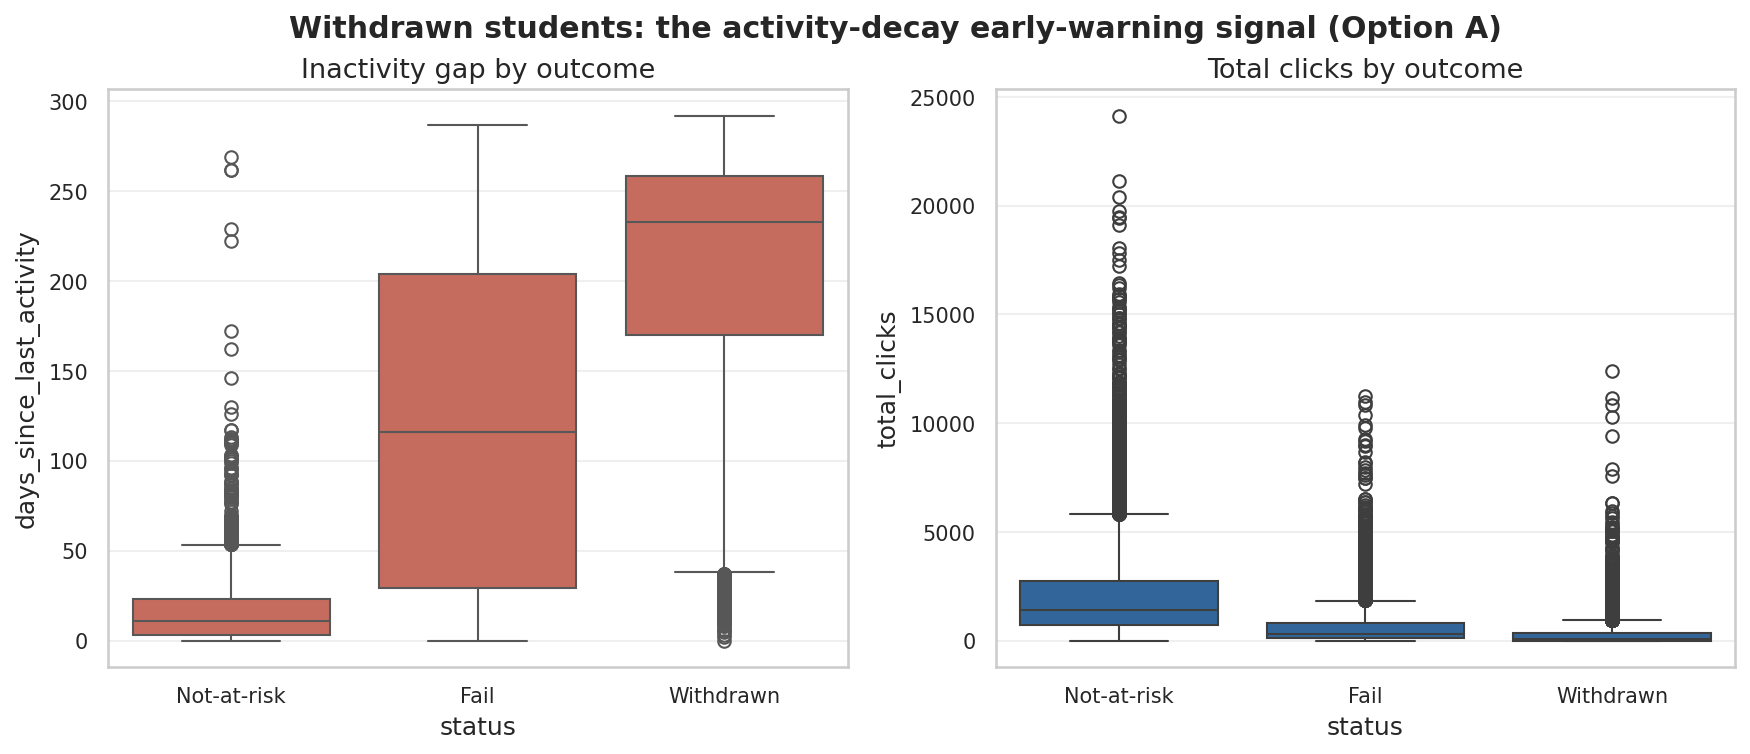

In [20]:
wd = eda.withdrawn_analysis(master)
print(json.dumps(wd, indent=2, ensure_ascii=False))
display(Image(filename=str(FIGS / 'withdrawn_activity_decay.png')))

## 9. Kết luận EDA & hàm ý cho mô hình

1. **Tín hiệu sớm (RQ1).** Đặc trưng hành vi/kết quả phân biệt hai lớp từ 10–20% và mạnh dần đơn điệu; 40–60% là vùng ổn định, khả thi.
2. **Hành vi ≫ nhân khẩu học (RQ1/RQ2).** Tương tác/kết quả đạt d > 2, còn liên hệ nhân khẩu học nhỏ (Cramér's V ≤ 0,15) → SHAP/LIME kỳ vọng xếp đặc trưng hành vi cao nhất.
3. **Mất cân bằng nhẹ (RQ3).** 52,8% at-risk → RQ3 định lượng SMOTE/ADASYN/class-weight bằng PR-AUC/recall.
4. **Đặc trưng tương quan cao (RQ2).** Các biến tương tác đa cộng tuyến có thể làm độ quan trọng giải thích kém ổn định — yếu tố chỉ số ổn định phải tính đến.
5. **Không rò rỉ.** Không biến nào tương quan ~hoàn hảo với nhãn; phép cắt thời gian loại sự kiện tương lai → ước lượng trên test đáng tin.

*Ba kết luận trọng tâm cho slide:* tín hiệu nằm ở **tương tác + điểm**; **không rò rỉ**; **dự đoán sớm khả thi từ ~20% khóa học**.